In [ ]:
import pandas as pd

In [2]:
cars= pd.read_csv(r"C:\Users\acreddy\Desktop\abc\DecisionTree_Classfier_and_Reg\data\cars_preprocessed_data.csv")

In [3]:
cars.head(2)

,symboling,wheel_base,length,width,height,curb_weight,num_of_cylinders,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0


In [4]:
X= cars.iloc[:,:-1]

In [5]:
y= cars.iloc[:, -1]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
# split the data into train and test
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.25, random_state=42)

In [8]:
X_train.shape,   y_train.shape

((153, 15), (153,))

In [9]:
X_test.shape, y_test.shape

((52, 15), (52,))

# Decision Tree Regressor

In [10]:
from sklearn.tree import DecisionTreeRegressor

In [12]:
# initialize the decision tree regressor
# here i have taken default criterion="squared_error". 
# you can use criterion: {“squared_error”, “friedman_mse”, “absolute_error”, “poisson”}
regressor= DecisionTreeRegressor()

In [13]:
# fit on train data
regressor.fit(X_train, y_train)

DecisionTreeRegressor()

In [14]:
# we can see the tree also how our decision Tree built a tree
# but its gonna too many calculations and too many features. So hard to plot 
from sklearn import tree
import matplotlib.pyplot as plt

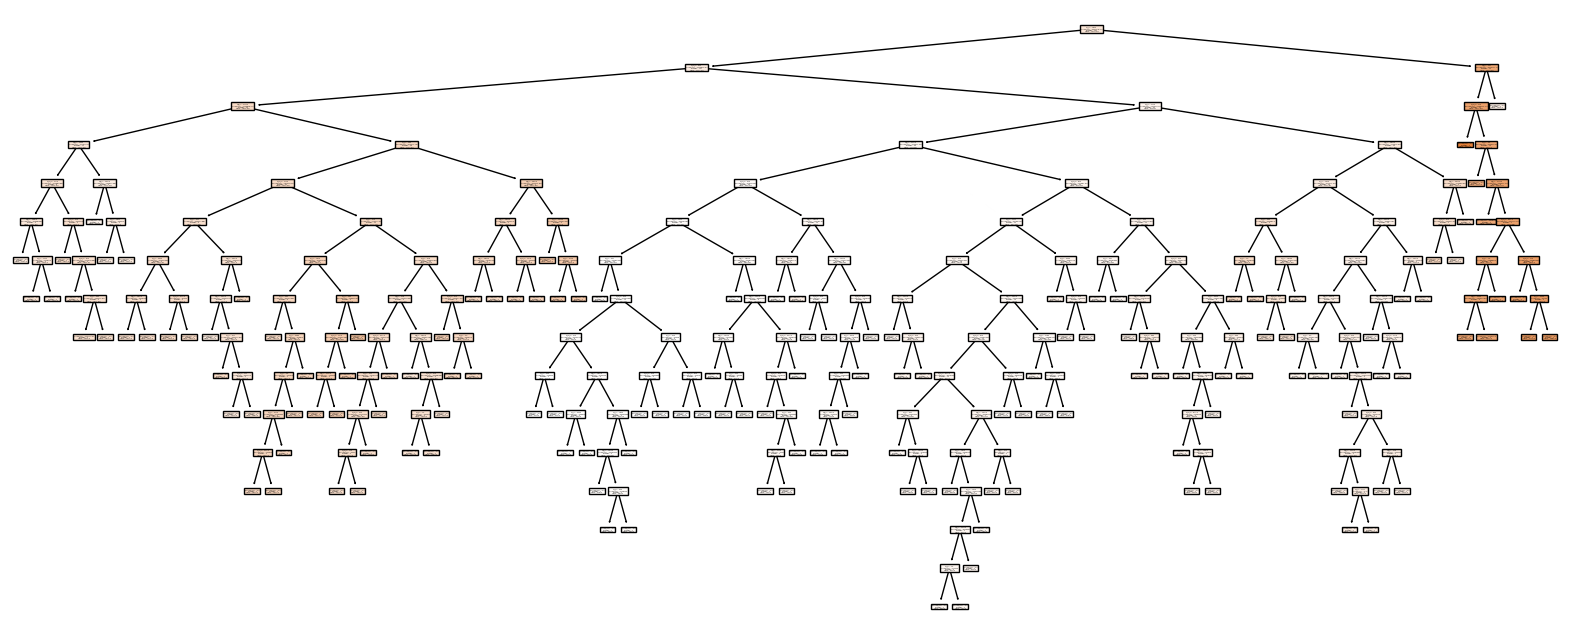

In [15]:
plt.figure(figsize=(20, 8))
tree.plot_tree(regressor, filled=True)
plt.show()

In [37]:
# predictions
y_pred= regressor.predict(X_test)

In [38]:
# lets get the metrics
from sklearn.metrics import r2_score, mean_squared_error

In [41]:
r2_score= r2_score(y_test, y_pred)
mse= mean_squared_error(y_test, y_pred)

In [42]:
r2_score

0.8705751168225628

In [43]:
mse

8691457.211538462

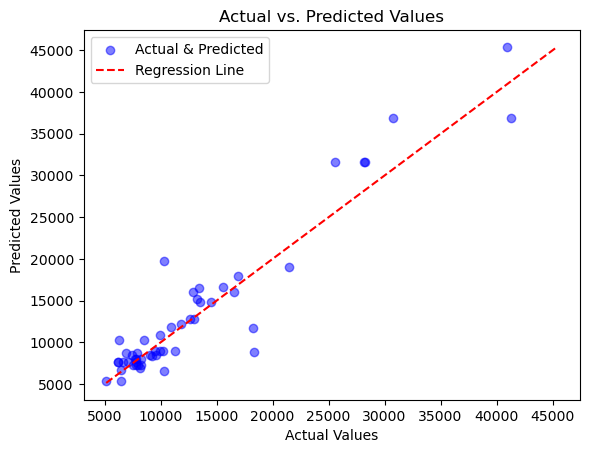

In [44]:
# lets plot how the model is fit on the data
plt.scatter(y_test, y_pred, color="blue", alpha=0.5, label="Actual & Predicted")

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Regression Line")


plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend()

# Show the plot
plt.show()

In [45]:
# Adjusted R-Square
R2_adjust= 1-(1-r2_square)*(len(cars)-1)/(len(cars)-X.shape[1]-1)
R2_adjust

0.8603033006973694

Note: r_square and Adjusted R_square both have better scores in Decision Tree Regressor than in Linear Regression we built earlier.

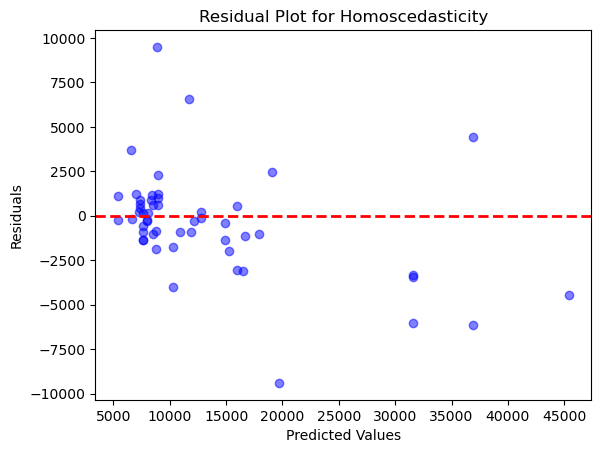

In [46]:
# check the homoscedacity and heteroscedacity using the Residual plot

residuals= y_test - y_pred

plt.scatter(y_pred, residuals, color= "blue", alpha=0.5)
plt.axhline(y=0, color="red", linestyle= "--", linewidth=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot for Homoscedasticity")
plt.show()

Note: residuals are not uniformly scattered. So its not showing up any homescedasticity. 